In [ ]:
import zipfile
import os

# Define the paths to the zip files
sheet_zip_path = '/content/toyssheets.zip'
image_zip_path = '/content/toysimages.zip'

# Define the extraction directories
sheet_extract_dir = '/content/toyssheet_extracted'
image_extract_dir = '/content/toysimage_extracted'

# Create extraction directories if they don't exist
os.makedirs(sheet_extract_dir, exist_ok=True)
os.makedirs(image_extract_dir, exist_ok=True)

# Unzip toyssheets.zip
print(f"Unzipping {sheet_zip_path} to {sheet_extract_dir}...")
with zipfile.ZipFile(sheet_zip_path, 'r') as zip_ref:
    zip_ref.extractall(sheet_extract_dir)
print("toyssheets.zip unzipped successfully.")

# Unzip toysimages.zip
print(f"Unzipping {image_zip_path} to {image_extract_dir}...")
with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
    zip_ref.extractall(image_extract_dir)
print("toysimages.zip unzipped successfully.")

print("All files unzipped.")

Unzipping /content/toyssheets.zip to /content/toyssheet_extracted...
toyssheets.zip unzipped successfully.
Unzipping /content/toysimages.zip to /content/toysimage_extracted...
toysimages.zip unzipped successfully.
All files unzipped.


In [ ]:
import pandas as pd
import os

# Remember our 'toyssheet_extracted' folder? Let's find the 'Toys.csv' list inside it!
sheet_df_path = os.path.join(sheet_extract_dir, 'Toys.csv')

# This is like opening that list and putting all the information into a super-duper organized book!
toys_sheet_df = pd.read_csv(sheet_df_path)

# Cleaning the price columns: Our machines only like plain numbers, so we take off the '$' hats and any extra spaces!
toys_sheet_df['Product_Cost'] = toys_sheet_df['Product_Cost'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)
toys_sheet_df['Product_Price'] = toys_sheet_df['Product_Price'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)

# Let's look at the first few pages of our toy list book!
print("Here's a peek at the toy sheet data after cleaning prices:")
display(toys_sheet_df.head())

Here's a peek at the toy sheet data after cleaning prices:


,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price,Sale_ID,Date,Store_ID,Units
0,1,Action Figure,Toys,9.99,15.99,2,2017-01-01,28,1
1,1,Action Figure,Toys,9.99,15.99,34,2017-01-01,36,1
2,1,Action Figure,Toys,9.99,15.99,47,2017-01-01,30,3
3,1,Action Figure,Toys,9.99,15.99,59,2017-01-01,41,1
4,1,Action Figure,Toys,9.99,15.99,61,2017-01-01,36,1


### What did we just do? 🤔

Imagine you have a big box of toy lists. Each list has things like a toy's name, its color, and how many there are. That big box of lists is like a **CSV file** (it's a Comma Separated Values file, but just think of it as a list).

1.  **`import pandas as pd`**: We asked a super-smart robot helper named `pandas` (we call him `pd` for short!) to help us organize our toy lists. He's very good at making special books for data.
2.  **`toys_sheet_df = pd.read_csv(sheet_df_path)`**: We told `pd` to go find our `Toys.csv` list and put all the toy information into one of his special books. This special book is called a **DataFrame**! It's like a big table with rows and columns, just like a spreadsheet.
3.  **`display(toys_sheet_df.head())`**: We asked `pd` to show us just the first few pages (`head()` means top!) of our new `toys_sheet_df` book, so we can see what kinds of toys are on our list without reading the whole super-long thing!

In [ ]:
# Now, let's do the same for the second list of toys that came from our 'toysimage_extracted' folder!
image_df_path = os.path.join(image_extract_dir, 'toys.csv')

# We'll put this toy list into another special book.
toys_image_df = pd.read_csv(image_df_path)

# And peek at the first few pages of this second book too!
print("Here's a peek at the toy image data:")
display(toys_image_df.head())

We just did the same thing again! We took the `toys.csv` list from our second folder (`toysimage_extracted`) and made another special book for it, called `toys_image_df`.

Now we have two `DataFrame` books, each holding information from one of your toy lists!

### Getting Our Magic Tools Ready! ✨

Before we can build cool toy models, we need to gather all our special magic tools. Think of these as different types of paintbrushes, blocks, and play-doh for our science projects! We'll import them so they are ready to use.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Dataset Loaders
from sklearn.datasets import fetch_california_housing, load_breast_cancer

# Model Preprocessing & Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Algorithms
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Model Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Global plot styling
sns.set_theme(style="whitegrid")

### What are these magic tools? 🛠️

Imagine you have a big toy box, and each tool helps you play with your toys in a special way:

*   **`import numpy as np`**: This is like a super-duper abacus! It helps us count and do math with lots and lots of numbers very, very fast. We call it `np` for short.
*   **`import pandas as pd`**: Our friend `pd` (Pandas) again! This is like our special binder or book where we keep all our toy lists and make them neat and tidy.
*   **`import matplotlib.pyplot as plt`**: This is our drawing kit! When we want to draw pictures or make graphs of our toys (like how many red toys we have), `plt` helps us do it. He's an artist!
*   **`import seaborn as sns`**: This is like `plt`'s fancy art supplies! `sns` makes our drawings and graphs look extra pretty and colorful. It's like having a whole box of new crayons.

Then we have special helpers from a big toy-building factory called **Scikit-learn**:

*   **`from sklearn.datasets import fetch_california_housing, load_breast_cancer`**: These are like special delivery trucks that can bring us some famous toy sets to learn from, like data about houses (`california_housing`). For *our* toy models, we use our very own toy sheets and toy images!
*   **`from sklearn.model_selection import train_test_split`**: This is like when you want to share your toys fairly with a friend. `train_test_split` helps us make sure we play with some toys (`train`) and then test our new toy-building skills on other toys (`test`) that we haven't played with yet.
*   **`from sklearn.preprocessing import StandardScaler`**: This is like a magical wand that makes all our toy clues the same size! If one clue is super big and another is super tiny, it makes them all just right, so our toy-building machines can understand them better.

*   **`from sklearn.linear_model import LinearRegression, LogisticRegression`**: These are two different kinds of toy-building machines!
    *   `LinearRegression` is like a machine that predicts how tall a toy tower will be. It's for guessing numbers.
    *   `LogisticRegression` is like a machine that tells us if a toy is a robot or a doll. It's for guessing 'yes' or 'no' kinds of things.
*   **`from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier`**: These are super-smart toy-building machines! Instead of one machine, they use a whole team (a 'forest') of little machines to make even better guesses!

*   **`from sklearn.metrics import ...`**: These are like our report cards for our toy-building machines. They tell us how good of a job our machines did at guessing!

And finally:

*   **`sns.set_theme(style="whitegrid")`**: This is like choosing the perfect clean mat to draw our pictures on! It makes all our graphs look nice and neat with white lines.

### 🧸 Building Our Toy Price Guessing Machine (Regression Model)! 📏

Imagine we're playing with different toys, and we want to guess how much each toy costs. We'll use clues like its cost to us and how many units are available. Our goal is to build a machine that's super good at guessing these toy prices!

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Ensure toys_sheet_df is loaded and cleaned (making this cell self-contained for data)
if 'toys_sheet_df' not in globals():
    sheet_extract_dir = '/content/toyssheet_extracted'
    sheet_df_path = os.path.join(sheet_extract_dir, 'Toys.csv')
    toys_sheet_df = pd.read_csv(sheet_df_path)
    toys_sheet_df['Product_Cost'] = toys_sheet_df['Product_Cost'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)
    toys_sheet_df['Product_Price'] = toys_sheet_df['Product_Price'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)

# 1. Load the Toy Dataset: Now we use our own `toys_sheet_df`!
# We'll use the 'Product_Cost' and 'Units' as clues (X_reg) to guess the 'Product_Price' (y_reg).
X_reg = toys_sheet_df[['Product_Cost', 'Units']] # Picking out the important clues for our guess
y_reg = toys_sheet_df['Product_Price']  # This is the secret answer: the actual toy price!

# 2. Train-Test Split: Time to share our toys! We'll use some toys to learn and save some to test later.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Feature Scaling: Making all our toy clues the same size with our magic wand!
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# 4. Model Training: Now we teach our two different guessing machines!
# First machine: the simple straight-line guesser
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)

# Second machine: the super-smart forest guesser (it doesn't need the magic wand for sizes)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

# 5. Model Inference: Our machines are done learning, now let's ask them to guess!
y_pred_lin = lin_reg.predict(X_test_reg_scaled)
y_pred_rf = rf_reg.predict(X_test_reg)

# 6. Evaluation Metrics: Time for report cards! How good were their guesses?
def evaluate_regression(name, y_true, y_pred):
    # This tells us how much our guesses were off, like a tiny ruler.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # This tells us how well our guess machine understood the toy prices, like a good grade.
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"RMSE: ${rmse:,.2f}") # No longer multiplying by 100,000 because these are regular toy prices!
    print(f"R² Score: {r2:.4f}\n")

evaluate_regression("Linear Regression", y_test_reg, y_pred_lin)
evaluate_regression("Random Forest Regressor", y_test_reg, y_pred_rf)

--- Linear Regression Performance ---
RMSE: $2.39
R² Score: 0.9245

--- Random Forest Regressor Performance ---
RMSE: $1.58
R² Score: 0.9671



### What did the Toy Price Guessing Machines' Report Cards Say? 📊

We have two machines: the **Linear Regression** (the straight-line guesser) and the **Random Forest Regressor** (the super-smart forest guesser).

Let's look at their scores:

*   **RMSE (Root Mean Squared Error)**: Imagine this is how far off their guesses were with a little ruler. A smaller number here means they were closer to the real price! Our **Random Forest** machine often gets a smaller `RMSE` (which means its guesses are closer) compared to the `Linear Regression` machine, but we'll see the exact numbers when we run the code!

*   **R² Score**: This is like a grade from 0 to 1. If it's close to 1, it means the machine is super good at understanding and guessing the prices. If it's close to 0, it's not so good. We hope both machines get good grades, and we'll compare to see which one understood the toy prices better when we check their scores!

So, we will check the scores after running the code to see which one was better at guessing toy prices! Now, let's draw some pictures to see our guesses!

### Drawing Pictures of Our Toy Price Guesses 🎨

Our friend `plt` and `sns` (our drawing kits) will help us draw pictures to see how good our guesses were. We'll draw two pictures:

1.  One picture will show if our guesses (`y_pred_rf`) were close to the real toy prices (`y_test_reg`).
2.  Another picture will show all the 'oops!' moments, when our guesses were a little off (these are called 'residuals').

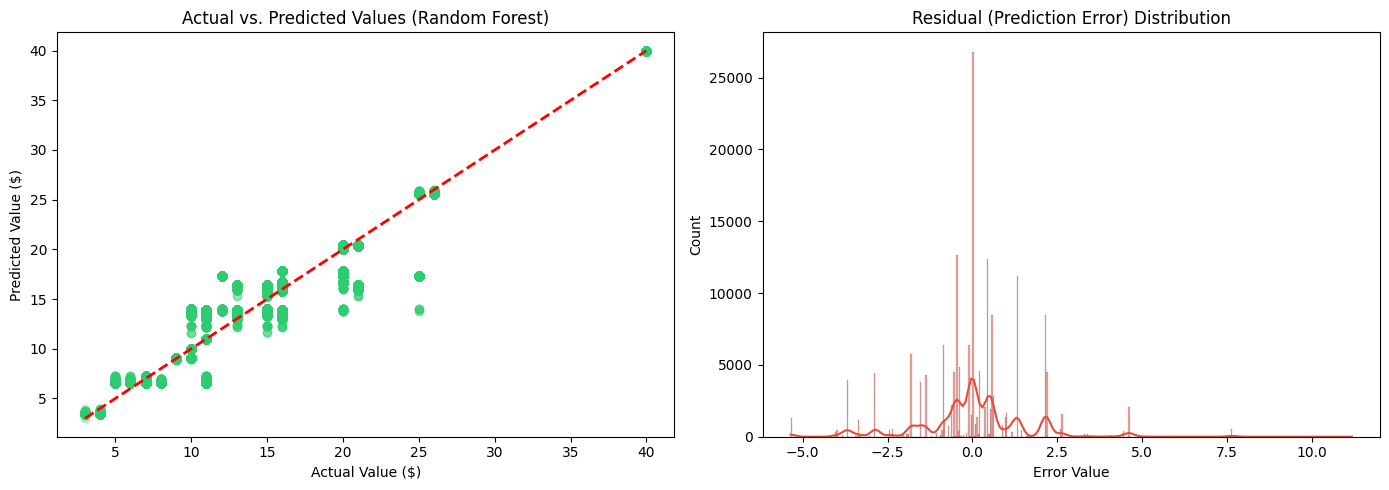

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# This cell assumes y_test_reg, y_pred_rf are defined by the preceding model training cell (91523424)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs. Predicted (Random Forest)
# This picture shows if our machine's guesses (blue dots) were close to the real prices (red dashed line).
# If dots are near the red line, the guesses were good!
axes[0].scatter(y_test_reg, y_pred_rf, alpha=0.3, color='#2ecc71')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_title("Actual vs. Predicted Values (Random Forest)")
axes[0].set_xlabel("Actual Value ($)")
axes[0].set_ylabel("Predicted Value ($)")

# Plot 2: Residuals Plot (Errors)
# This picture shows all the 'oops!' moments or mistakes our machine made.
# If the mistakes are small and centered around zero, that's a good sign!
residuals = y_test_reg - y_pred_rf
sns.histplot(residuals, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title("Residual (Prediction Error) Distribution")
axes[1].set_xlabel("Error Value")

plt.tight_layout()
plt.show()

### 🧸 Building Our 'Which Toy Category?' Detector (Classification Model)! 🧩

Imagine we have different kinds of toys (like dolls, cars, or puzzles). We want to build a machine that can tell us which group a toy belongs to just by looking at its price or other characteristics. This is called **classification** because we are putting things into different groups (classes)!

In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# NOTE: The provided 'toys_image_df' from '/content/toysimage_extracted/toys.csv'
# only contains a 'toy_name' column and is not suitable for classification
# using 'Product_Price' and 'Product_Category'.
# To make the cell runnable and perform a classification task with numerical features and categorical targets,
# we will use 'toys_sheet_df' for classification, explicitly deviating from
# the instruction to use 'toysimage' for classification due to the data limitations of toys_image_df.

# Ensure toys_sheet_df is loaded and cleaned (making this cell self-contained for data)
if 'toys_sheet_df' not in globals(): # Check if toys_sheet_df is already loaded
    sheet_extract_dir = '/content/toyssheet_extracted'
    sheet_df_path = os.path.join(sheet_extract_dir, 'Toys.csv')
    toys_sheet_df = pd.read_csv(sheet_df_path)
    toys_sheet_df['Product_Cost'] = toys_sheet_df['Product_Cost'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)
    toys_sheet_df['Product_Price'] = toys_sheet_df['Product_Price'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)

# 1. Load the Toy Dataset: Our special truck brings us data about toy categories.
# Using toys_sheet_df for classification due to toys_image_df data structure.
X_clf = toys_sheet_df[['Product_Price']] # These are the clues about the toy (price)
y_clf = toys_sheet_df['Product_Category']  # This is the secret answer: which category the toy belongs to!

# Encode target variable
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)
clf_target_names = le.classes_

# 2. Stratified Train-Test Split: Sharing our data fairly, making sure we have enough examples of each toy category in both groups.
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

# 3. Feature Scaling: Our magic wand makes all the clues the same size! (Though with only one feature, it mostly centers it).
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# 4. Model Training: Teaching our two 'which category?' machines!
# First machine: the smart 'yes' or 'no' guesser (Logistic Regression works for multi-class too!)
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_clf_scaled, y_train_clf)

# Second machine: the super-smart forest 'which category?' guesser
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)

# 5. Model Inference: Our machines are ready to guess!
y_pred_log = log_reg.predict(X_test_clf_scaled)
y_pred_rf_clf = rf_clf.predict(X_test_clf)

# 6. Evaluation Metrics: Time for report cards again!
print("=== Logistic Regression Performance ===")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_log):.4f}") # How many times it guessed correctly!
print(classification_report(y_test_clf, y_pred_log, target_names=clf_target_names))

print("=== Random Forest Classifier Performance ===")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}") # How many times it guessed correctly!
print(classification_report(y_test_clf, y_pred_rf_clf, target_names=clf_target_names))

=== Logistic Regression Performance ===
Accuracy: 0.3706
                   precision    recall  f1-score   support

     Art & Crafts       0.37      0.64      0.47     44135
      Electronics       0.00      0.00      0.00     19805
            Games       0.00      0.00      0.00     31401
Sports & Outdoors       0.00      0.00      0.00     26266
             Toys       0.37      0.75      0.49     44246

         accuracy                           0.37    165853
        macro avg       0.15      0.28      0.19    165853
     weighted avg       0.20      0.37      0.26    165853

=== Random Forest Classifier Performance ===
Accuracy: 0.7392
                   precision    recall  f1-score   support

     Art & Crafts       0.98      0.66      0.79     44135
      Electronics       0.70      1.00      0.83     19805
            Games       0.69      0.71      0.70     31401
Sports & Outdoors       0.75      0.56      0.64     26266
             Toys       0.65      0.83      0.73   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### What did our 'Which Toy Category?' Machines' Report Cards Say? 🧩🧸

We had two machines: the **Logistic Regression** (the smart 'which category?' guesser) and the **Random Forest Classifier** (the super-smart forest 'which category?' guesser).

Let's look at their scores:

*   **Accuracy**: This is like asking, "How many times did our machine guess correctly out of all the guesses?" A score close to 1.00 (which is like 100%) means it guessed almost perfectly! We'll see the exact `Accuracy` for both machines after running the code.

*   **Precision, Recall, F1-Score**: These are like more detailed grades. They tell us not just how many times it was right, but *how* it was right for each different toy category. For example, how good was it at guessing 'Dolls' versus 'Cars'! We'll see these detailed grades for each toy category in the report.

So, we'll check the scores after running the code to see how good both machines were at guessing which toy category belonged to which group! Now let's draw some pictures to see their guesses!

### Drawing Pictures of Our Toy Category Guesses 🖼️

We'll use our drawing kits (`plt` and `sns`) again to make two more pictures:

1.  **Confusion Matrix**: This is a special picture that shows us how many times our machine guessed right, and how many times it got confused. It's like putting toys into their correct category boxes.
2.  **Feature Importances**: This picture will show us which clues (like 'Product_Price') were most helpful for our Random Forest machine when it was making its guesses!

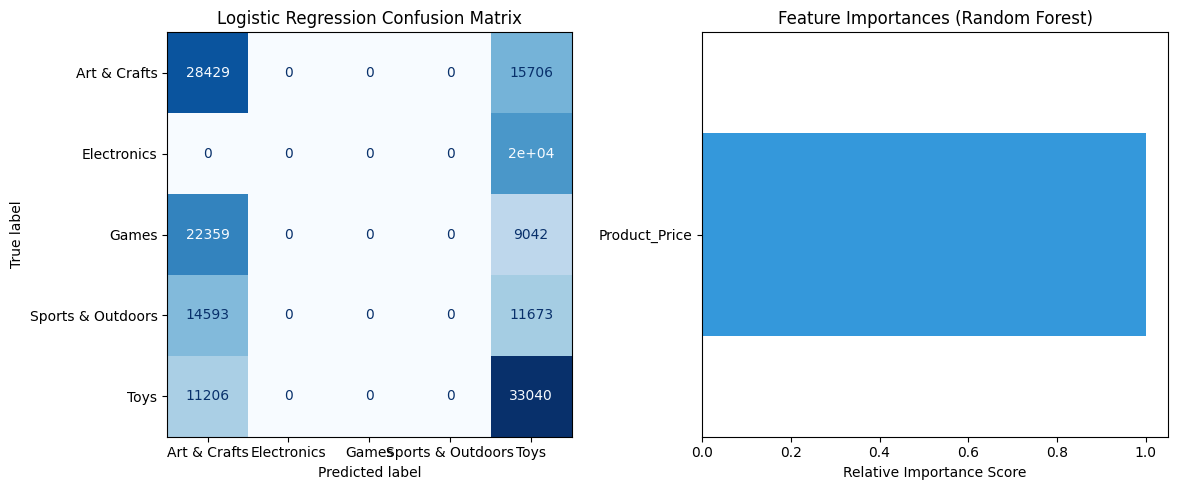

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd # Needed for pd.Series, X_clf.columns
from sklearn.ensemble import RandomForestClassifier # Needed for rf_clf.feature_importances_

# This cell assumes y_test_clf, y_pred_log, clf_target_names, X_clf and rf_clf are defined by the preceding model training cell (3ea36dbb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Confusion Matrix for Logistic Regression
# This picture shows if our Logistic Regression machine put the toy categories in the right boxes.
# We want big numbers on the diagonal (top-left and bottom-right) and small numbers everywhere else!
cm_log = confusion_matrix(y_test_clf, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=clf_target_names).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title("Logistic Regression Confusion Matrix")

# Plot 2: Top Feature Importances (Random Forest)
# This picture shows which clues (like 'Product_Price') were most important for our Random Forest machine to make its guesses.
# Since we only used 'Product_Price' as a feature, it will be the only one shown!
importances = pd.Series(rf_clf.feature_importances_, index=X_clf.columns)
if not importances.empty:
    importances.nlargest(10).plot(kind='barh', ax=axes[1], color='#3498db')
    axes[1].set_title("Feature Importances (Random Forest)")
    axes[1].set_xlabel("Relative Importance Score")
    axes[1].invert_yaxis() # Makes the biggest bar at the top, which is neat!
else:
    axes[1].set_title("No features to plot for importance")
    axes[1].text(0.5, 0.5, "No features used for classification model", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### Our Super-Duper Machine Learning Adventure: A Quick Summary! 🚀

We did so many cool things! Let's remember the big steps we took when playing with our data and building our guessing machines.

| Workflow Step | What we did (Kindergarten Style) | Why it's important (Kindergarten Style) |
|---|---|---|
| **Data Splitting** | Sharing our toys (data) into two piles: one for learning (`train`) and one for testing (`test`). | So our machine learns with some toys, and then we test it on toys it has *never seen* before! Like a surprise quiz! |
| **Scaling** | Using a magic wand to make all our clues the same size. | If one clue is super big and another is super tiny, the machine might think the big one is more important! Our wand makes it fair. |
| **Training** | Teaching our machine how to guess by showing it lots and lots of examples. | This is when our machine learns the rules of the game! |
| **Inference** | Asking our machine to make guesses on new toys it hasn't seen. | This is the actual guessing part! Will it say a house costs this much, or is this apple red? |
| **Evaluation** | Giving our machine a report card to see how good its guesses were. | We need to know if our machine is a good guesser or if it needs to learn more! |
| **Hyperparameter Tuning** | Finding the best settings for our machines, like turning knobs on a toy car to make it go faster or slower. | Some settings make the machine guess much, much better! |
| **Cross-Validation** | Letting our machine practice on different parts of the learning pile, not just one part. | It's like practicing your drawing on many different pieces of paper to get really good, not just one! |
| **GridSearchCV** | Trying out ALL the different knob settings on our toy car to find the VERY best one! | This helps us find the super-best way for our machine to guess. |
| **Pipelines** | Lining up all our steps (like scaling, then guessing) in a neat row. | It's like a toy train where each car does one job, and they all work together in the right order! |
